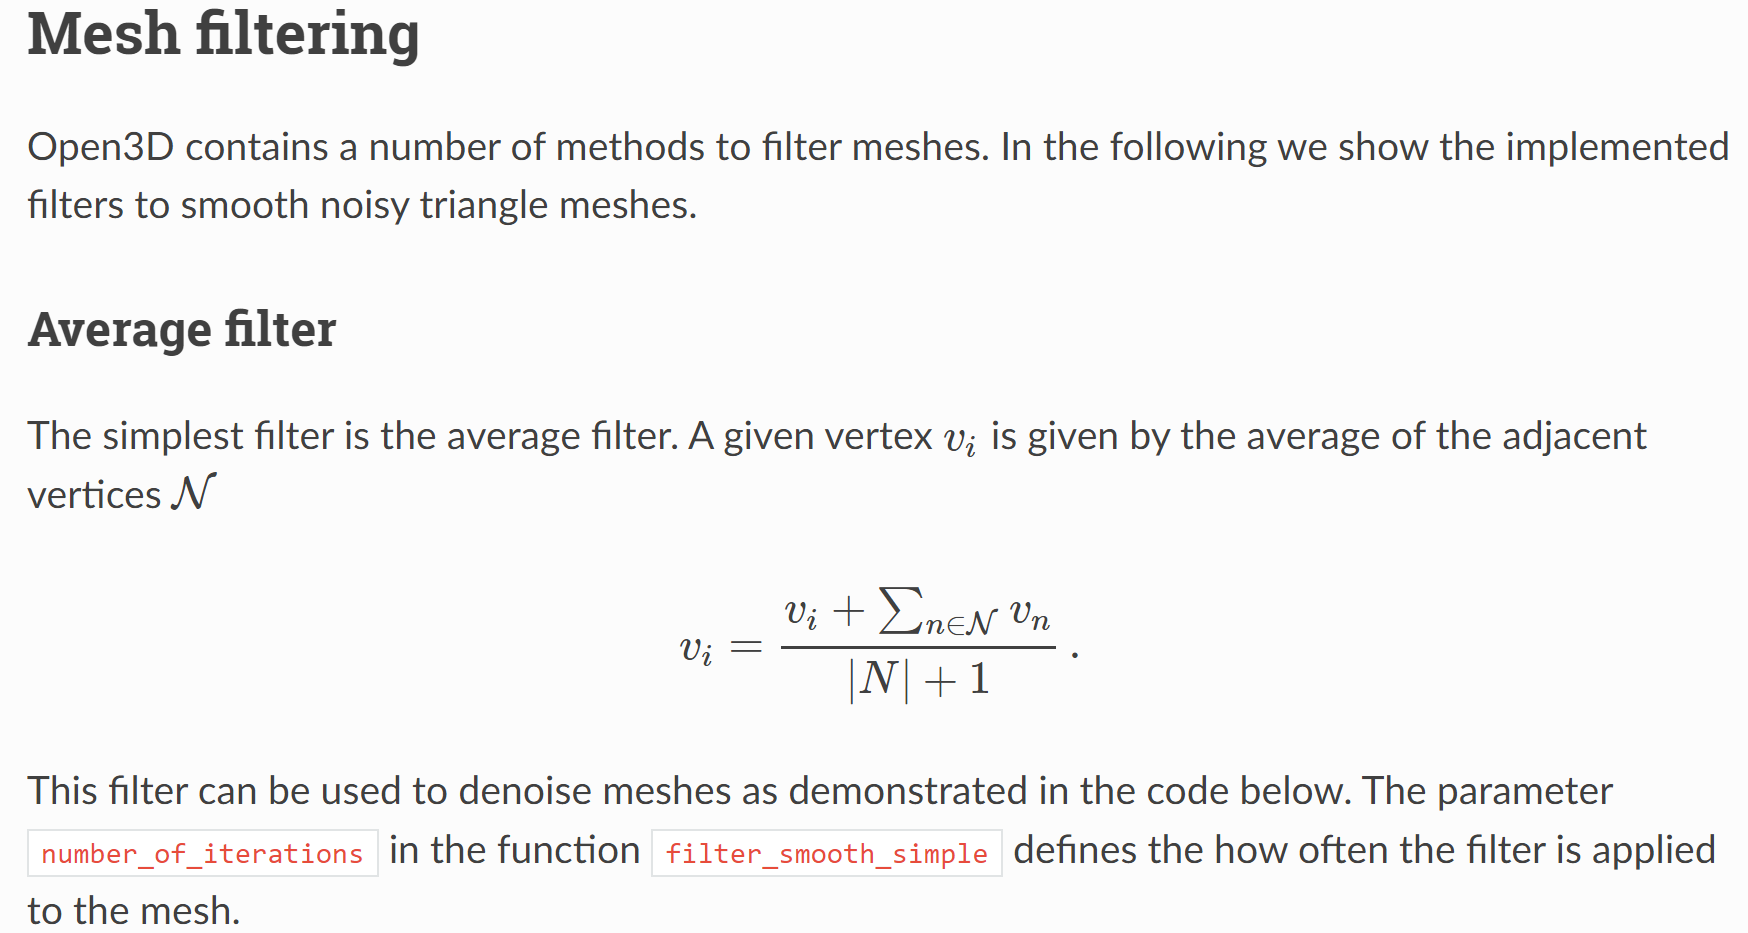

| 特性 | 說明 |
|------|------|
| 方法 | 平均鄰點 (uniform Laplacian) |
| 是否會縮小 mesh | **會**（shrink） |
| 是否保持 edge feature | 不會 |
| 是否使用 cotangent weights | 不使用 |
| 是否保持體積 | 不保持 |
| 適合用途 | 快速平滑、去噪 |

In [ ]:
import open3d as o3d
import numpy as np
import copy
print('create noisy mesh')
knot_mesh = o3d.data.KnotMesh()
mesh_in = o3d.io.read_triangle_mesh(knot_mesh.path)
mesh_in.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh_in])
mesh_be_smooth = copy.deepcopy(mesh_in)
vertices = np.asarray(mesh_be_smooth.vertices)
noise = 5
vertices += np.random.uniform(0, noise, size=vertices.shape)
mesh_be_smooth.vertices = o3d.utility.Vector3dVector(vertices)
mesh_be_smooth.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh_be_smooth])

print('filter with average with 1 iteration')
mesh_out = mesh_be_smooth.filter_smooth_simple(number_of_iterations=1)
mesh_out.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh_out])

print('filter with average with 5 iterations')
mesh_out = mesh_be_smooth.filter_smooth_simple(number_of_iterations=5)
mesh_out.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh_out])

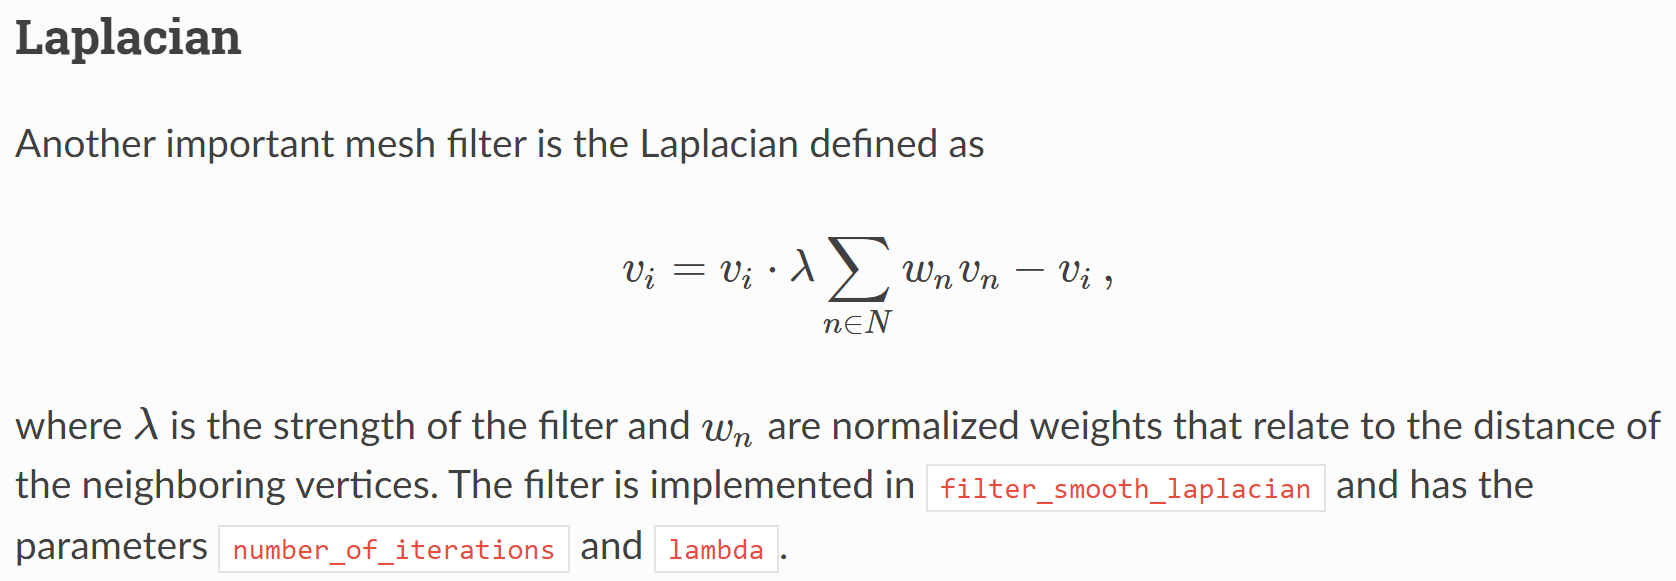

In [ ]:
mesh_be_smooth = copy.deepcopy(mesh_in)
o3d.visualization.draw_geometries([mesh_in])
vertices = np.asarray(mesh_be_smooth.vertices)
noise = 5
vertices += np.random.uniform(0, noise, size=vertices.shape)
mesh_be_smooth.vertices = o3d.utility.Vector3dVector(vertices)
mesh_be_smooth.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh_be_smooth])
print('filter with Laplacian with 1 iterations')
mesh_out = mesh_be_smooth.filter_smooth_laplacian(number_of_iterations=1)
mesh_out.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh_out])

print('filter with Laplacian with 5 iterations')
mesh_out = mesh_be_smooth.filter_smooth_laplacian(number_of_iterations=5)
mesh_out.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh_out])

| 特性分類 | 說明 |
|----------|------|
| 方法類型 | Cotangent-weighted Laplacian smoothing |
| 權重類型 | 使用 cot(α) + cot(β) 的幾何權重（cotangent weight） |
| 是否考慮幾何形狀 | ✔ 有，會根據三角形形狀與角度調整權重 |
| 平滑效果品質 | ✔ 中高品質，能保留更多細節與形狀 |
| 收縮程度（shrink） | 中等（比 simple smoothing 小，但仍會 shrink） |
| 對尖角特徵的保留 | 中等（比 simple 好，但仍會被平滑） |
| 是否支援 λ（lambda）控制強度 | ✔ `lambda_` 參數控制每次疊代平滑程度 |
| 是否支援多次疊代 | ✔ `number_of_iterations` |
| 是否可處理邊界頂點 | ✔ 可，但邊界只用單邊角（cot α）計算 |
| 是否為體積保留平滑 | ❌ 不會保體積（會縮） |
| 是否需要 mesh 有三角拓撲 | ✔ 必須，因為需要角度 α、β |
| 是否比 simple smoothing 更精確 | ✔ 明顯更精確、更符合幾何 |
| 是否會造成反轉 (flip) | 很少，但在薄表面、大 λ 可能發生 |
| 適用範圍 | 適合平滑 CAD、3D scan、三角 mesh 表面 |

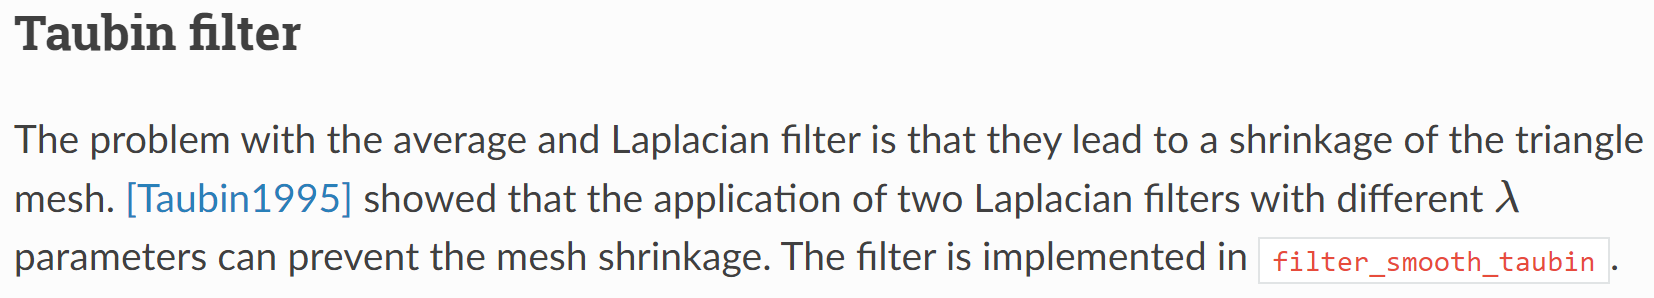

In [ ]:
mesh_be_smooth = copy.deepcopy(mesh_in)
o3d.visualization.draw_geometries([mesh_in])
vertices = np.asarray(mesh_be_smooth.vertices)
noise = 5
vertices += np.random.uniform(0, noise, size=vertices.shape)
mesh_be_smooth.vertices = o3d.utility.Vector3dVector(vertices)
mesh_be_smooth.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh_be_smooth])
print('filter with Taubin with 10 iterations')
mesh_out = mesh_be_smooth.filter_smooth_taubin(number_of_iterations=10)
mesh_out.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh_out])

print('filter with Taubin with 100 iterations')
mesh_out = mesh_be_smooth.filter_smooth_taubin(number_of_iterations=100)
mesh_out.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh_out])

| 特性分類 | 說明 |
|----------|------|
| 方法類型 | Taubin λ–μ smoothing (non-shrinking Laplacian) |
| 使用 Laplacian | ✔ 使用 cotangent Laplacian |
| 平滑步驟 | 兩步（λ 正平滑 + μ 負平滑） |
| 收縮 (shrink) | ❌ 幾乎不縮小 |
| 保體積 | ✔ 是的 |
| 效果 | 高品質平滑、保形狀 |
| Feature 保留 | 中高 |
| 是否需多次迭代 | ✔ `number_of_iterations` |
| 參數 | `lambda_` (> 0), `mu` (< 0) |
| 適用場景 | 修補噪聲、3D scan 平滑、CAD 模型修整 |

| 方法 | 效果 | 是否 shrink | 是否保細節 |
|------|------|-------------|------------|
| `filter_smooth_simple()` | 快速粗糙 | **會** | ❌ |
| `filter_smooth_laplacian()` | 權重 Laplacian（cotangent） | **少一點 shrink** | ⚠️ 中等 |
| `filter_smooth_taubin()` | Taubin smoothing | **不會 shrink** | ✔ 最佳 |

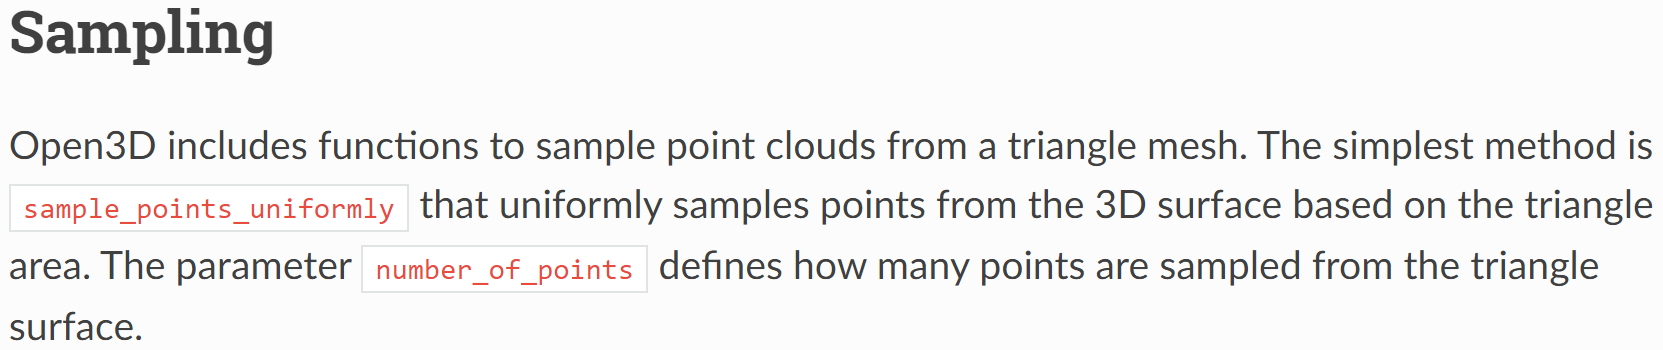

In [ ]:
mesh = o3d.geometry.TriangleMesh.create_sphere()
mesh.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh])
pcd = mesh.sample_points_uniformly(number_of_points=500)
o3d.visualization.draw_geometries([pcd])

In [17]:
bunny = o3d.data.BunnyMesh()
mesh = o3d.io.read_triangle_mesh(bunny.path)
mesh.compute_vertex_normals()

o3d.visualization.draw_geometries([mesh])
pcd = mesh.sample_points_uniformly(number_of_points=500)
o3d.visualization.draw_geometries([pcd])

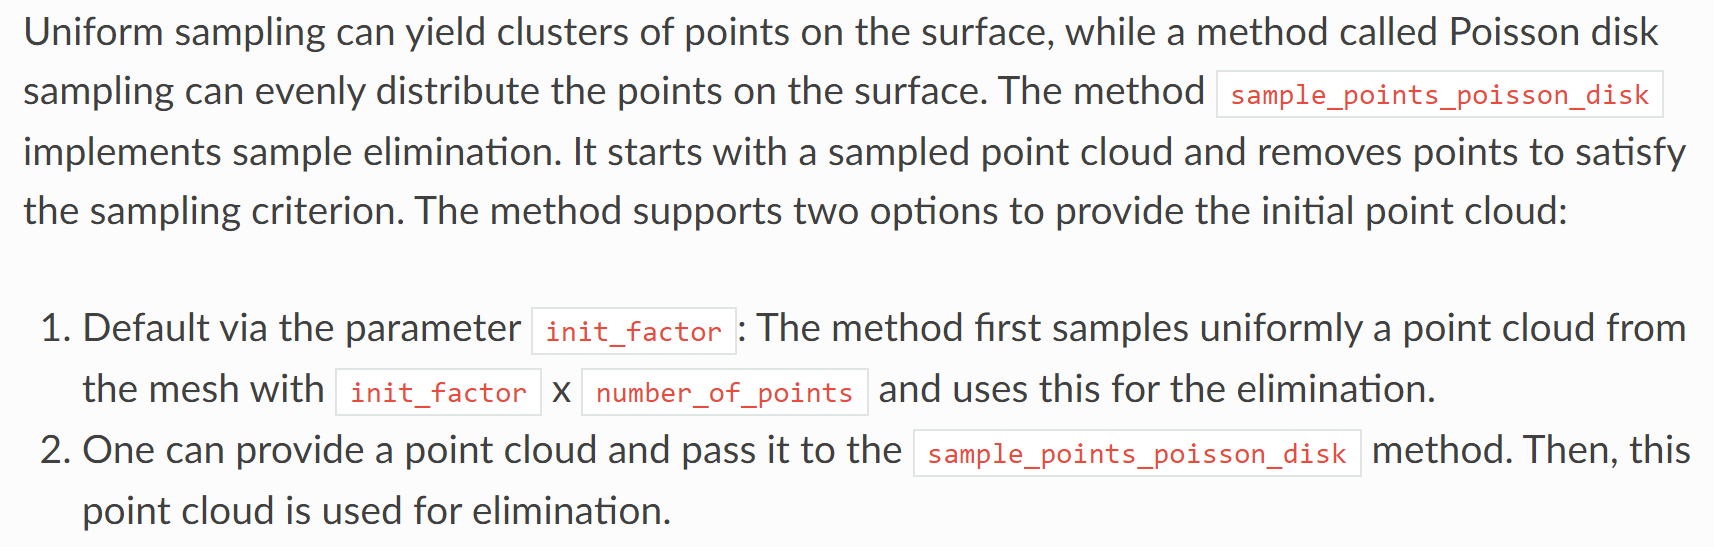

In [18]:
mesh = o3d.geometry.TriangleMesh.create_sphere()
pcd = mesh.sample_points_poisson_disk(number_of_points=500, init_factor=5)
o3d.visualization.draw_geometries([pcd])

pcd = mesh.sample_points_uniformly(number_of_points=2500)
o3d.visualization.draw_geometries([pcd])
pcd = mesh.sample_points_poisson_disk(number_of_points=500, pcl=pcd)
o3d.visualization.draw_geometries([pcd])

In [19]:
bunny = o3d.data.BunnyMesh()
mesh = o3d.io.read_triangle_mesh(bunny.path)
mesh.compute_vertex_normals()

pcd = mesh.sample_points_poisson_disk(number_of_points=500, init_factor=5)
o3d.visualization.draw_geometries([pcd])

pcd = mesh.sample_points_uniformly(number_of_points=2500)
o3d.visualization.draw_geometries([pcd])
pcd = mesh.sample_points_poisson_disk(number_of_points=500, pcl=pcd)
o3d.visualization.draw_geometries([pcd])

Poisson Disk sampling 參數

| 參數名稱 | 型態 | 意義 |
|----------|--------|-------|
| number_of_points | int | 要取的點數量 |
| init_factor | float | 前處理 oversampling 倍數（預設：5） |
| pcl | PointCloud（可選） | 若提供，代表用來初始化 Poisson disk 的點 |
| use_triangle_normal | bool | 是否使用三角形法向量來引導取樣 |
| seed | int | 隨機 seed，用於可重現性 |

Uniform sampling vs. Poisson Disk sampling

| 方法 | 均勻性 | 最小距離控制 | 視覺品質 | 是否 clump |
|------|---------|----------------|------------|--------------|
| Uniform sampling | 中等 | ❌ 無 | 一般 | 會 clump |
| Poisson Disk sampling | ✔ 高 | ✔ 有 | ✔ 非常好 | ❌ 不會 |

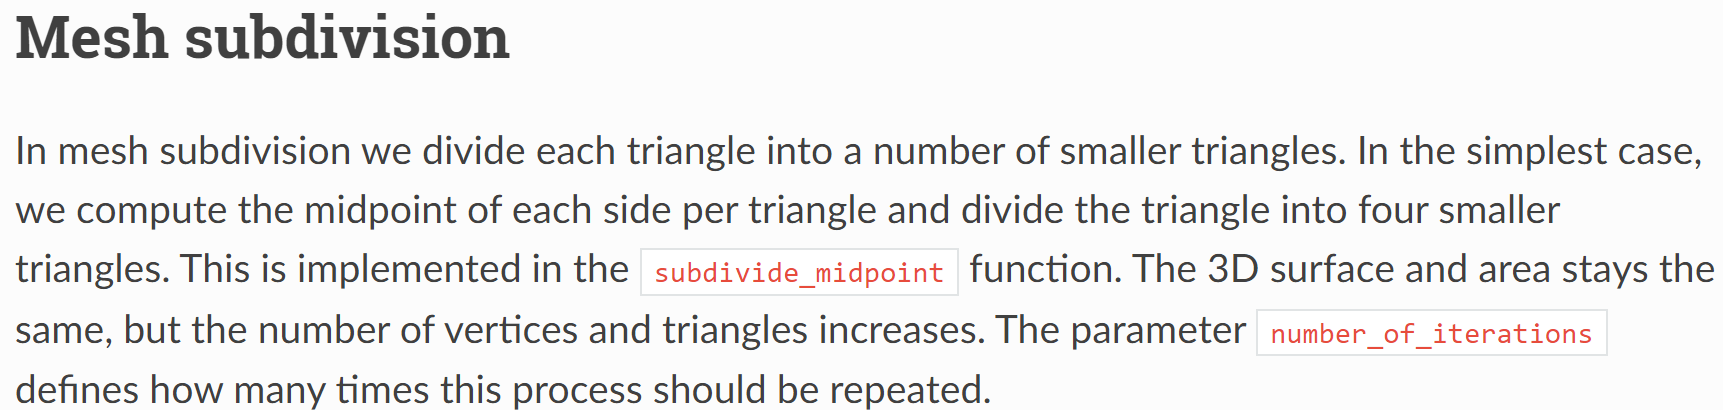

In [ ]:
mesh = o3d.geometry.TriangleMesh.create_box()
mesh.compute_vertex_normals()
print(
    f'The mesh has {len(mesh.vertices)} vertices and {len(mesh.triangles)} triangles'
)
o3d.visualization.draw_geometries([mesh], mesh_show_wireframe=True)
mesh = mesh.subdivide_midpoint(number_of_iterations=5)
print(
    f'After subdivision it has {len(mesh.vertices)} vertices and {len(mesh.triangles)} triangles'
)
o3d.visualization.draw_geometries([mesh], mesh_show_wireframe=True)

| 特性 | 說明 |
|------|------|
| 細分方式 | Midpoint subdivision（邊中點法） |
| 平滑 | ❌ 不平滑（Loop 才會） |
| 每次細分面數增加 | ×4 |
| 每次細分點數增加 | 新增每條邊的中點 |
| 保持幾何形狀 | ✔ 基本上維持原 mesh 幾何，不變形 |
| 是否能製造平滑曲面 | ❌ 無（Loop subdivision 才能） |
| 拓撲變化 | ✔ 會產生新的三角拓撲 |
| 是否保持 volume | ✔ 大致保持，因為只做幾何 split |
| 適合用途 | 簡單細分、提高 mesh 密度、不做平滑 |

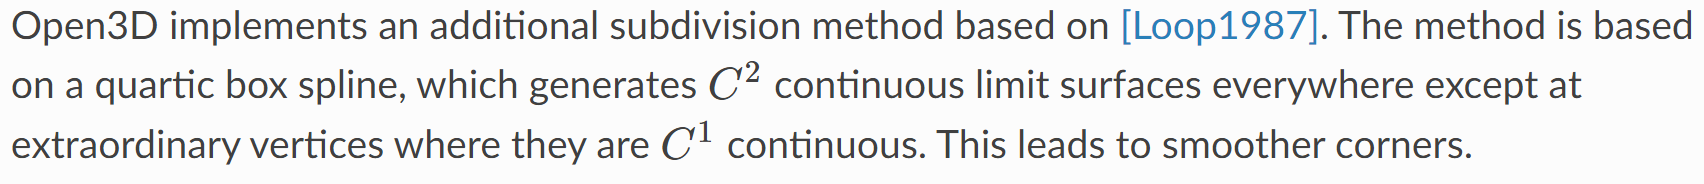

In [ ]:
mesh = o3d.geometry.TriangleMesh.create_sphere()
mesh.compute_vertex_normals()
print(
    f'The mesh has {len(mesh.vertices)} vertices and {len(mesh.triangles)} triangles'
)
o3d.visualization.draw_geometries([mesh], mesh_show_wireframe=True)
mesh = mesh.subdivide_loop(number_of_iterations=2)
print(
    f'After subdivision it has {len(mesh.vertices)} vertices and {len(mesh.triangles)} triangles'
)
o3d.visualization.draw_geometries([mesh], mesh_show_wireframe=True)

| 特性 | 說明 |
|------|------|
| 細分方式 | Loop subdivision（平滑細分曲面） |
| 新頂點建立方式 | 使用 Loop mask（非中點） |
| 原頂點位置更新 | ✔ 會被平滑更新 |
| 曲面光滑度 | 非常高（C1 連續） |
| 單次細分面數變化 | ×4 |
| 是否保持整體形狀 | ✔ 保形狀但會更光滑 |
| 是否會縮小 | ⚠️ 一點點（常態） |
| 是否比 midpoint 好 | ✔ 完勝 midpoint，在品質上 |
| 適合用途 | 渲染、雕刻、可視化、CAD、動畫、角色模型 |

In [ ]:
knot_mesh = o3d.data.KnotMesh()
mesh = o3d.io.read_triangle_mesh(knot_mesh.path)
mesh.compute_vertex_normals()
print(
    f'The mesh has {len(mesh.vertices)} vertices and {len(mesh.triangles)} triangles'
)
o3d.visualization.draw_geometries([mesh], mesh_show_wireframe=True)
mesh = mesh.subdivide_loop(number_of_iterations=1)
print(
    f'After subdivision it has {len(mesh.vertices)} vertices and {len(mesh.triangles)} triangles'
)
o3d.visualization.draw_geometries([mesh], mesh_show_wireframe=True)

| 項目 | Midpoint subdivision | Loop subdivision |
|------|-----------------------|------------------|
| 新邊頂點 | 中點 (平均) | Loop mask（幾何插值，平滑） |
| 原頂點是否平滑 | ❌ 不平滑 | ✔ 平滑 |
| 是否變曲面 | ❌ 不會 | ✔ 會變平滑曲面 |
| 最終外觀 | 只是密度變高 | 更光滑、更自然 |
| 適用 | 純細分用途 | 高品質細分（渲染、模型） |

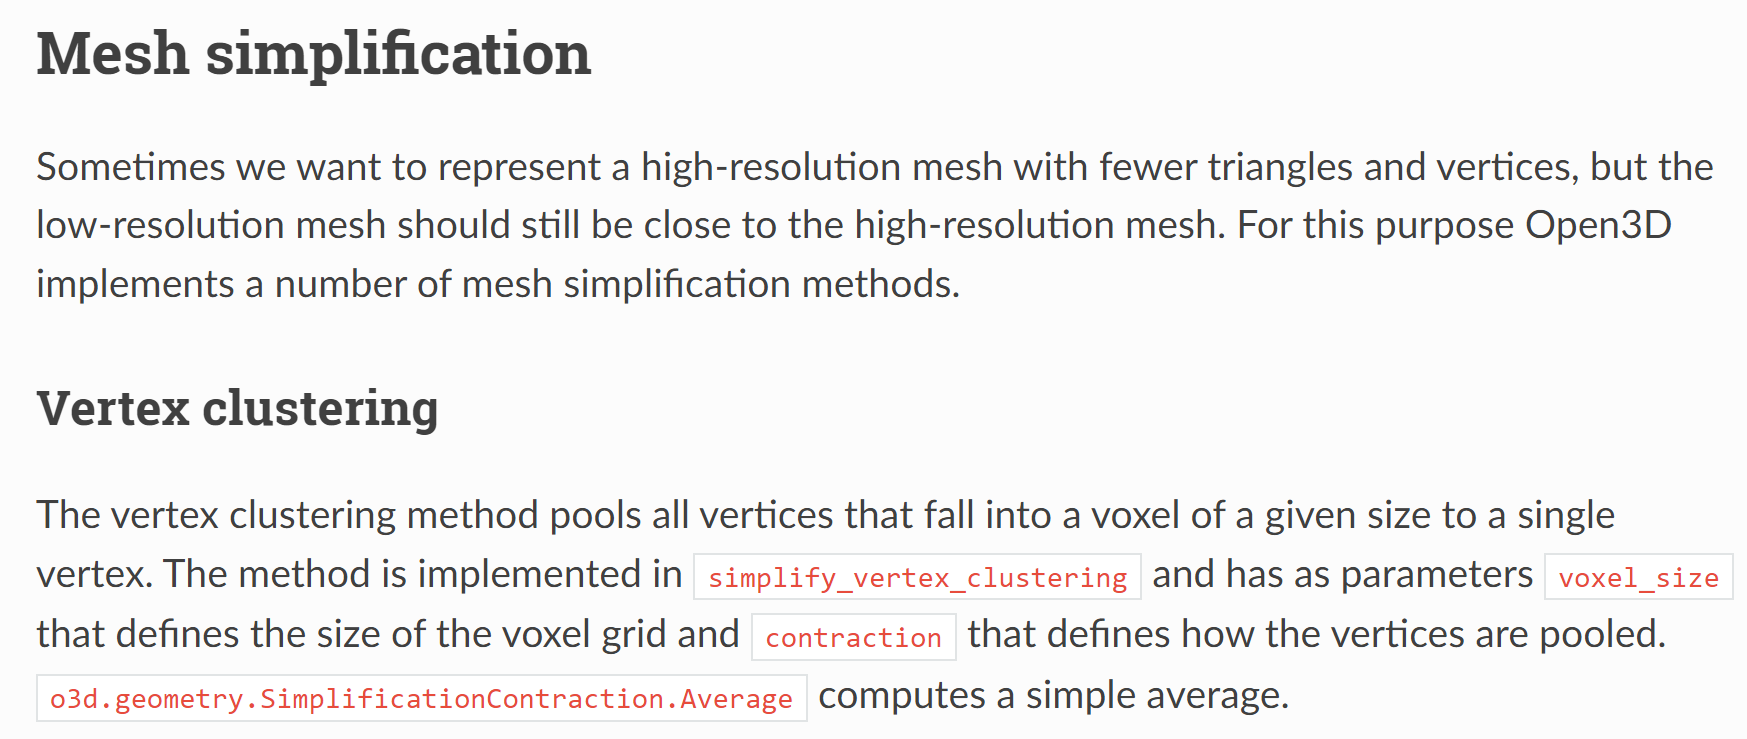

Average : The vertex positions are computed by the averaging.

Quadric : The vertex positions are computed by minimizing the distance to the adjacent triangle

In [ ]:
bunny = o3d.data.BunnyMesh()
mesh_in = o3d.io.read_triangle_mesh(bunny.path)
mesh_in.compute_vertex_normals()

print(
    f'Input mesh has {len(mesh_in.vertices)} vertices and {len(mesh_in.triangles)} triangles'
)
o3d.visualization.draw_geometries([mesh_in])

voxel_size = max(mesh_in.get_max_bound() - mesh_in.get_min_bound()) / 32
print(f'voxel_size = {voxel_size:e}')
mesh_smp = mesh_in.simplify_vertex_clustering(
    voxel_size=voxel_size,
    contraction=o3d.geometry.SimplificationContraction.Quadric)
print(
    f'Simplified mesh has {len(mesh_smp.vertices)} vertices and {len(mesh_smp.triangles)} triangles'
)
o3d.visualization.draw_geometries([mesh_smp])

voxel_size = max(mesh_in.get_max_bound() - mesh_in.get_min_bound()) / 16
print(f'voxel_size = {voxel_size:e}')
mesh_smp = mesh_in.simplify_vertex_clustering(
    voxel_size=voxel_size,
    contraction=o3d.geometry.SimplificationContraction.Quadric)
print(
    f'Simplified mesh has {len(mesh_smp.vertices)} vertices and {len(mesh_smp.triangles)} triangles'
)
o3d.visualization.draw_geometries([mesh_smp])

In [ ]:
import open3d as o3d


bunny = o3d.data.BunnyMesh()
mesh_in = o3d.io.read_triangle_mesh(bunny.path)
mesh_in.compute_vertex_normals()

print(
    f'Input mesh has {len(mesh_in.vertices)} vertices and {len(mesh_in.triangles)} triangles'
)
o3d.visualization.draw_geometries([mesh_in])

voxel_size = max(mesh_in.get_max_bound() - mesh_in.get_min_bound()) / 32
print(f'voxel_size = {voxel_size:e}')
mesh_smp = mesh_in.simplify_vertex_clustering(
    voxel_size=voxel_size,
    contraction=o3d.geometry.SimplificationContraction.Average)
print(
    f'Simplified mesh has {len(mesh_smp.vertices)} vertices and {len(mesh_smp.triangles)} triangles'
)
o3d.visualization.draw_geometries([mesh_smp])

voxel_size = max(mesh_in.get_max_bound() - mesh_in.get_min_bound()) / 16
print(f'voxel_size = {voxel_size:e}')
mesh_smp = mesh_in.simplify_vertex_clustering(
    voxel_size=voxel_size,
    contraction=o3d.geometry.SimplificationContraction.Average)
print(
    f'Simplified mesh has {len(mesh_smp.vertices)} vertices and {len(mesh_smp.triangles)} triangles'
)
o3d.visualization.draw_geometries([mesh_smp])

| contraction 模式 | 採用方法 | 計算方式 | 品質 | 速度 | 適用場合 |
|------------------|------------|------------|--------|--------|--------------|
| Average | 平均頂點 | v_new = mean(v_i) | 低 | ✔ 很快 | 粗糙 decimation、預處理 |
| Quadric | QEM（Quadric Error Metrics） | 最小化 v^T Q v | ✔ 高 | 中等 | 精準 decimation、保形狀、保邊界 |

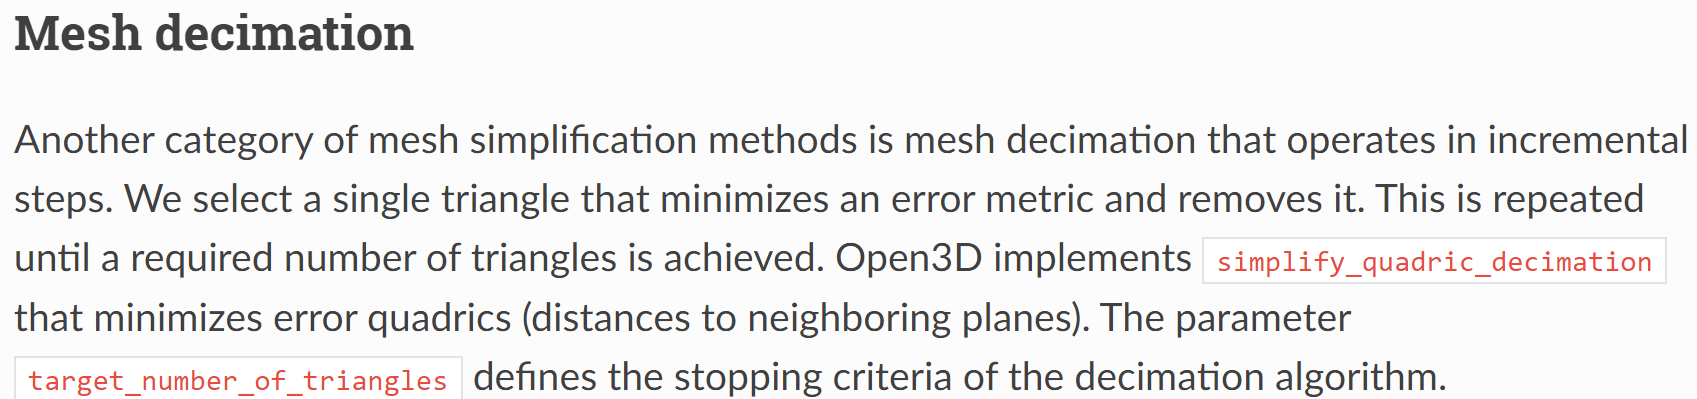

In [ ]:
import open3d as o3d


bunny = o3d.data.BunnyMesh()
mesh_in = o3d.io.read_triangle_mesh(bunny.path)
mesh_in.compute_vertex_normals()


mesh_smp = mesh_in.simplify_quadric_decimation(target_number_of_triangles=6500)
print(
    f'Simplified mesh has {len(mesh_smp.vertices)} vertices and {len(mesh_smp.triangles)} triangles'
)
o3d.visualization.draw_geometries([mesh_smp])

mesh_smp = mesh_in.simplify_quadric_decimation(target_number_of_triangles=1700)
print(
    f'Simplified mesh has {len(mesh_smp.vertices)} vertices and {len(mesh_smp.triangles)} triangles'
)
o3d.visualization.draw_geometries([mesh_smp])

| 特性 | 說明 |
|------|------|
| 減面方式 | Edge collapse（邊收縮） |
| 誤差度量 | Quadric Error Metrics（QEM） |
| 新點位置 | 使 vᵀ Q v 最小的點（最佳化） |
| 優先選擇 | collapse error 最小的邊 |
| 保形狀能力 | ✔ 很高（業界標準） |
| 速度 | 快（比 clustering 慢，但品質高） |
| 支援邊界保留 | ✔（邊界誤差較大，不會優先 collapse） |
| 適用模型 | CAD、掃描模型、動畫模型 |
| 比較 | 品質遠優於 Average / Clustering |

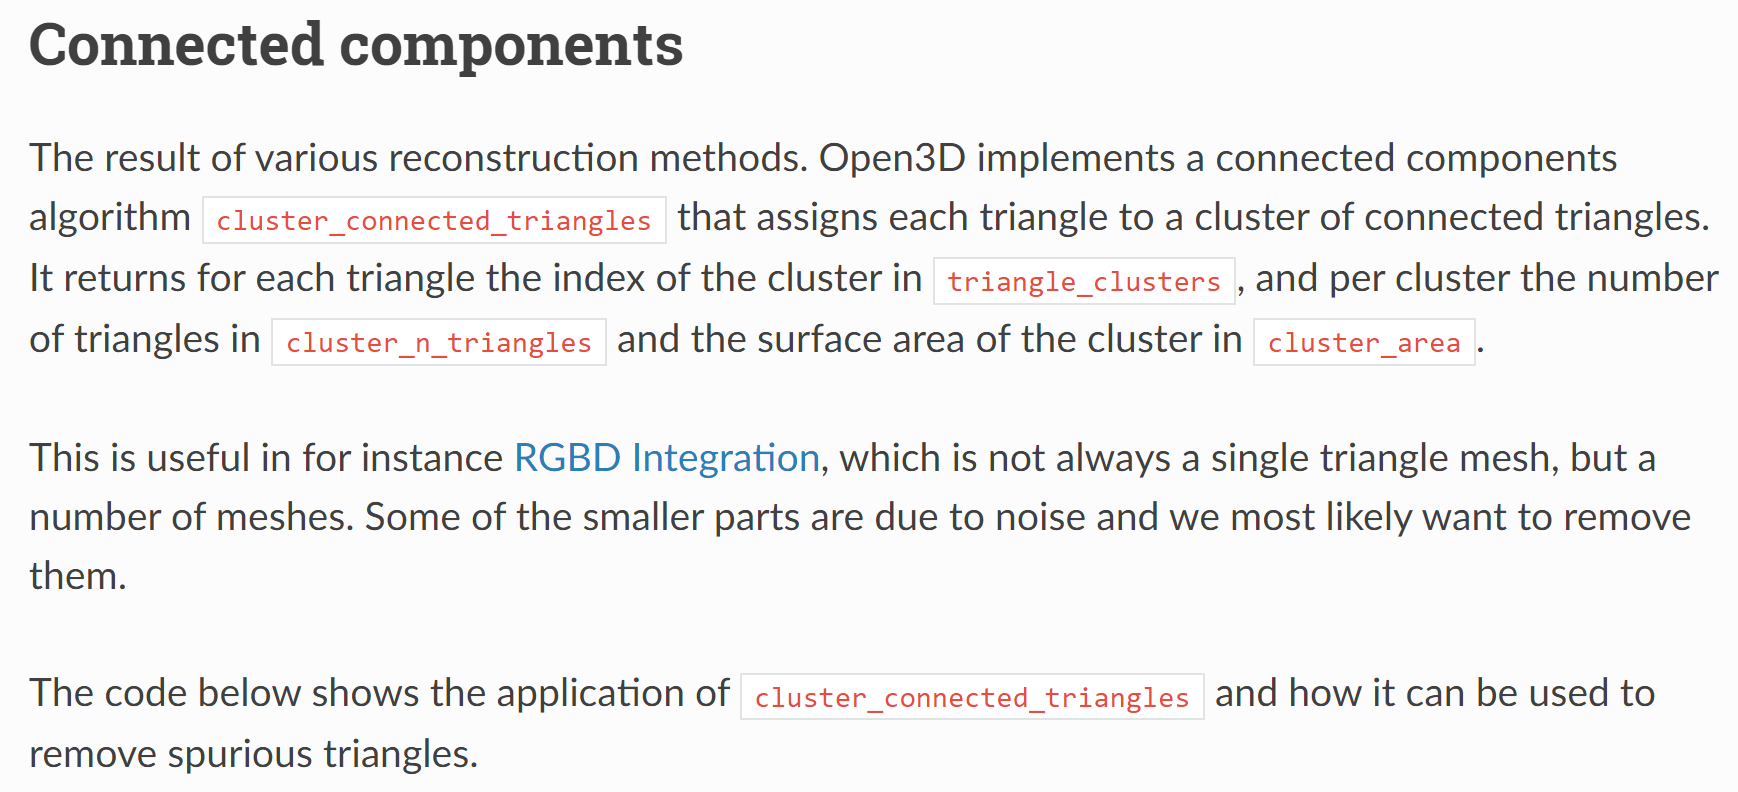


| 回傳項目 | 說明 |
|----------|------|
| triangle_clusters | 長度 = #triangles，每個元素是該三角形的 cluster ID |
| cluster_n_triangles | 每個 cluster 包含的三角形數量 |
| cluster_area | 每個 cluster 的表面積 |

In [ ]:
import open3d as o3d
import numpy as np

print("Generate data")
bunny = o3d.data.BunnyMesh()
mesh = o3d.io.read_triangle_mesh(bunny.path)
mesh.compute_vertex_normals()

mesh = mesh.subdivide_midpoint(number_of_iterations=2)
vert = np.asarray(mesh.vertices)
min_vert, max_vert = vert.min(axis=0), vert.max(axis=0)
for _ in range(30):
    cube = o3d.geometry.TriangleMesh.create_box()
    cube.scale(0.005, center=cube.get_center())
    cube.translate(
        (
            np.random.uniform(min_vert[0], max_vert[0]),
            np.random.uniform(min_vert[1], max_vert[1]),
            np.random.uniform(min_vert[2], max_vert[2]),
        ),
        relative=False,
    )
    mesh += cube
mesh.compute_vertex_normals()
print("Show input mesh")
o3d.visualization.draw_geometries([mesh])

In [ ]:
import copy

print("Cluster connected triangles")
with o3d.utility.VerbosityContextManager(
        o3d.utility.VerbosityLevel.Debug) as cm:
    triangle_clusters, cluster_n_triangles, cluster_area = (
        mesh.cluster_connected_triangles())
triangle_clusters = np.asarray(triangle_clusters)
cluster_n_triangles = np.asarray(cluster_n_triangles)
cluster_area = np.asarray(cluster_area)

print("Show mesh with small clusters removed")
mesh_0 = copy.deepcopy(mesh)
print(triangle_clusters)
print(cluster_n_triangles)
triangles_to_remove = cluster_n_triangles[triangle_clusters] < 100
print(triangles_to_remove)
mesh_0.remove_triangles_by_mask(triangles_to_remove)
o3d.visualization.draw_geometries([mesh_0])

In [ ]:
print("Show largest cluster")
mesh_1 = copy.deepcopy(mesh)
largest_cluster_idx = cluster_n_triangles.argmax()
triangles_to_remove = triangle_clusters != largest_cluster_idx
mesh_1.remove_triangles_by_mask(triangles_to_remove)
o3d.visualization.draw_geometries([mesh_1])

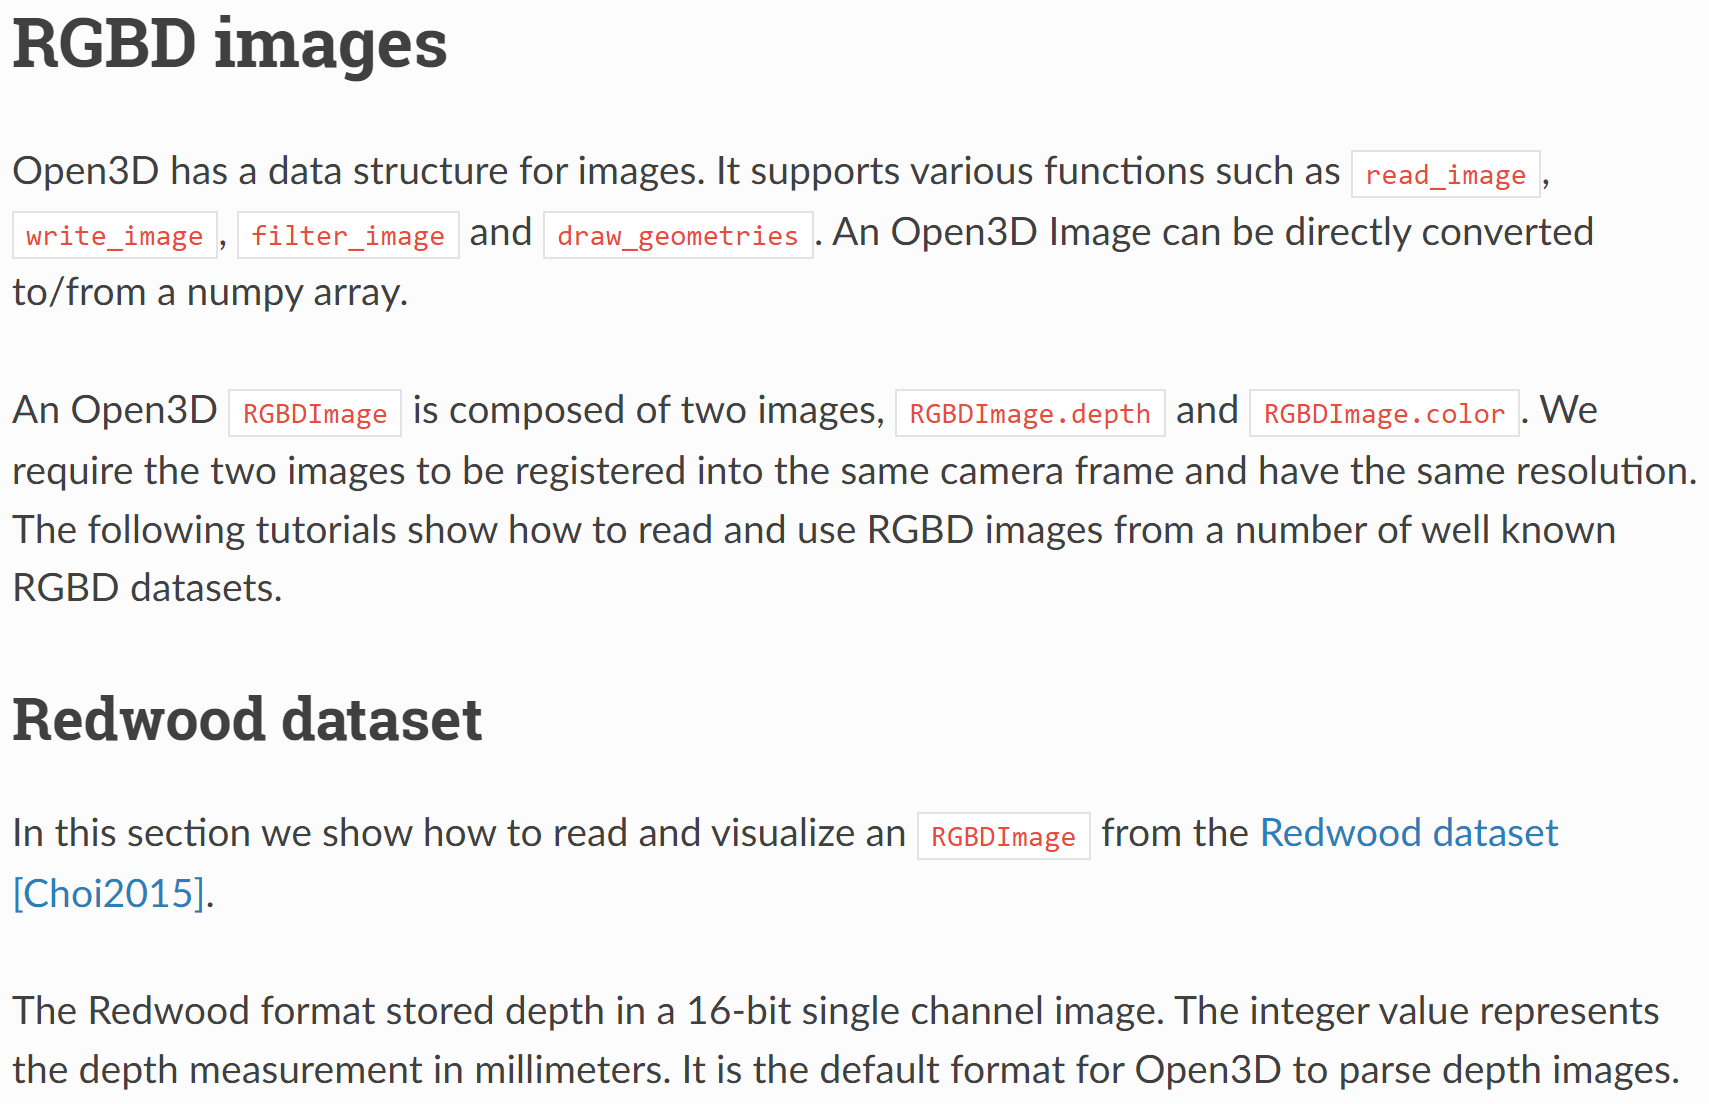

In [ ]:
print("Read Redwood dataset")
redwood_rgbd = o3d.data.SampleRedwoodRGBDImages()
color_raw = o3d.io.read_image(redwood_rgbd.color_paths[0])
depth_raw = o3d.io.read_image(redwood_rgbd.depth_paths[0])
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw, depth_raw)
print(redwood_rgbd.color_paths)
print(redwood_rgbd.depth_paths)
print(rgbd_image)


In [ ]:
from matplotlib import pyplot as plt
plt.subplot(1, 2, 1)
plt.title('Redwood grayscale image')
plt.imshow(rgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('Redwood depth image')
plt.imshow(rgbd_image.depth)
plt.show()

In [ ]:
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image,
    o3d.camera.PinholeCameraIntrinsic(
        o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault))
# Flip it, otherwise the pointcloud will be upside down
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
o3d.visualization.draw_geometries([pcd])

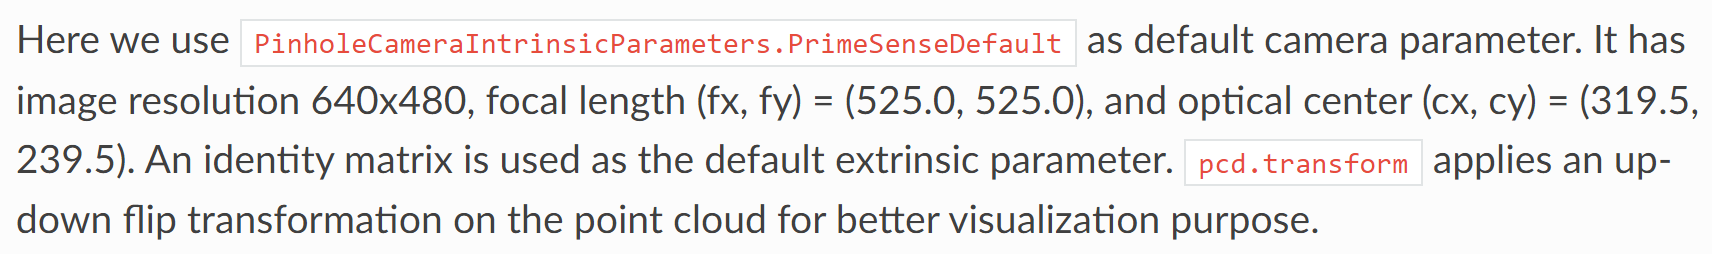

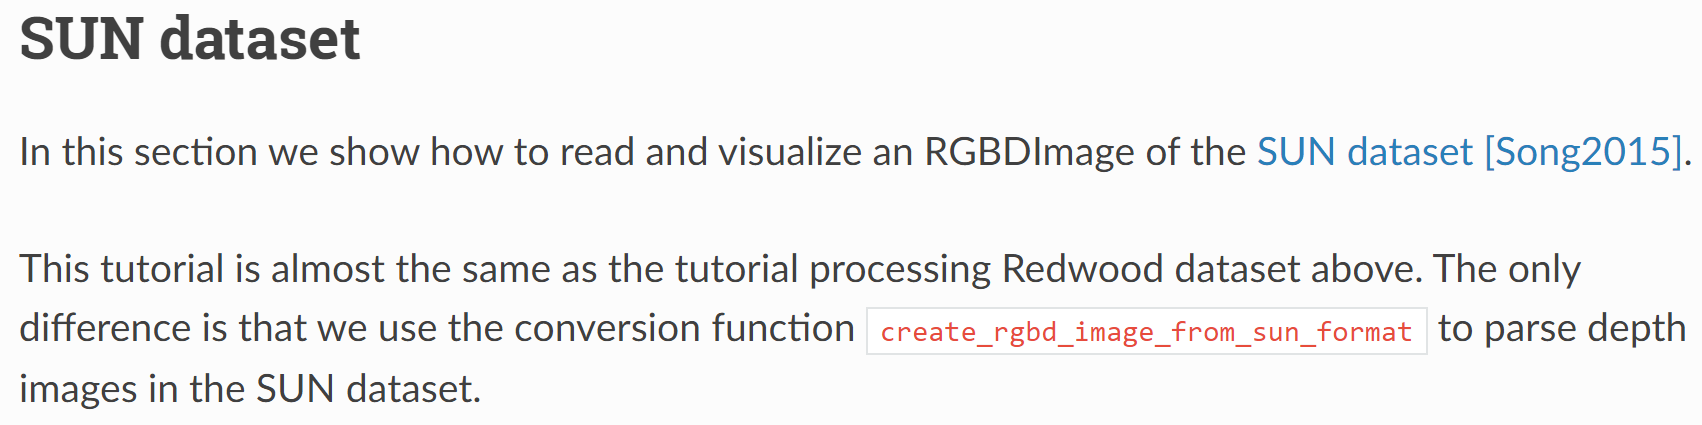

In [ ]:
import matplotlib.pyplot as plt
print("Read SUN dataset")
sun_rgbd = o3d.data.SampleSUNRGBDImage()
color_raw = o3d.io.read_image(sun_rgbd.color_path)
depth_raw = o3d.io.read_image(sun_rgbd.depth_path)
srgbd_image = o3d.geometry.RGBDImage.create_from_sun_format(color_raw, depth_raw)
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(color_raw, depth_raw)
print(redwood_rgbd.color_paths)
print(redwood_rgbd.depth_paths)
print(rgbd_image)

plt.subplot(1, 2, 1)
plt.title('SUN grayscale image')
plt.imshow(srgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('SUN depth image')
plt.imshow(srgbd_image.depth)
plt.show()
plt.subplot(1, 2, 1)
plt.title('SUN (color&depth) grayscale image')
plt.imshow(rgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('SUN (color&depth) depth image')
plt.imshow(rgbd_image.depth)
plt.show()

In [30]:
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    srgbd_image,
    o3d.camera.PinholeCameraIntrinsic(
        o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault))
# Flip it, otherwise the pointcloud will be upside down
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
o3d.visualization.draw_geometries([pcd])

pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image,
    o3d.camera.PinholeCameraIntrinsic(
        o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault))
# Flip it, otherwise the pointcloud will be upside down
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
o3d.visualization.draw_geometries([pcd])

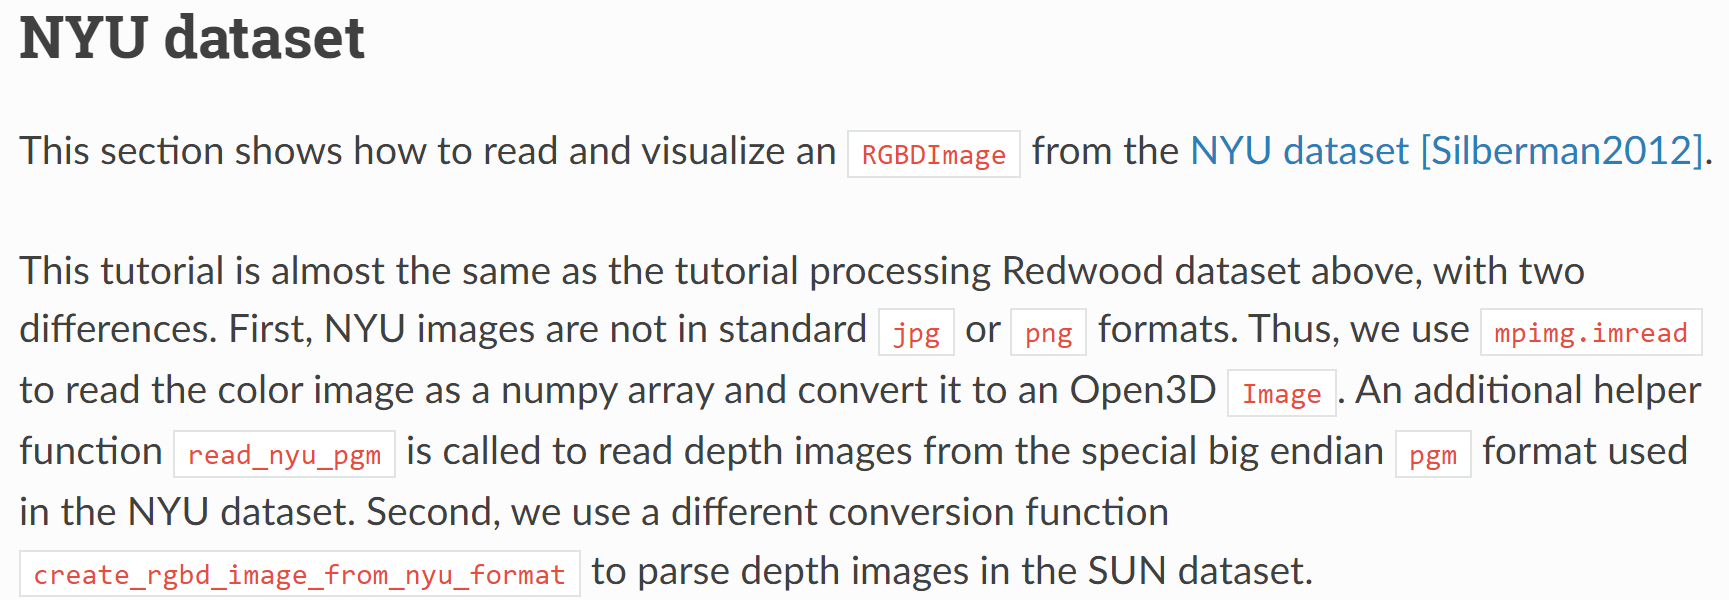

In [ ]:
import matplotlib.image as mpimg
import re
import matplotlib.pyplot as plt

# This is special function used for reading NYU pgm format
# as it is written in big endian byte order.
def read_nyu_pgm(filename, byteorder='>'):
    with open(filename, 'rb') as f:
        buffer = f.read()
    try:
        header, width, height, maxval = re.search(
            b"(^P5\s(?:\s*#.*[\r\n])*"
            b"(\d+)\s(?:\s*#.*[\r\n])*"
            b"(\d+)\s(?:\s*#.*[\r\n])*"
            b"(\d+)\s(?:\s*#.*[\r\n]\s)*)", buffer).groups()
    except AttributeError:
        raise ValueError("Not a raw PGM file: '%s'" % filename)
    img = np.frombuffer(buffer,
                        dtype=byteorder + 'u2',
                        count=int(width) * int(height),
                        offset=len(header)).reshape((int(height), int(width)))
    img_out = img.astype('u2')
    return img_out


print("Read NYU dataset")
# Open3D does not support ppm/pgm file yet. Not using o3d.io.read_image here.
# MathplotImage having some ISSUE with NYU pgm file. Not using imread for pgm.
nyu_rgbd = o3d.data.SampleNYURGBDImage()
color_raw = mpimg.imread(nyu_rgbd.color_path)
depth_raw = read_nyu_pgm(nyu_rgbd.depth_path)
color = o3d.geometry.Image(color_raw)
depth = o3d.geometry.Image(depth_raw)
rgbd_image = o3d.geometry.RGBDImage.create_from_nyu_format(color, depth)
print(rgbd_image)

In [ ]:
plt.subplot(1, 2, 1)
plt.title('NYU grayscale image')
plt.imshow(rgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('NYU depth image')
plt.imshow(rgbd_image.depth)
plt.show()

In [33]:
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image,
    o3d.camera.PinholeCameraIntrinsic(
        o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault))
# Flip it, otherwise the pointcloud will be upside down
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
o3d.visualization.draw_geometries([pcd])

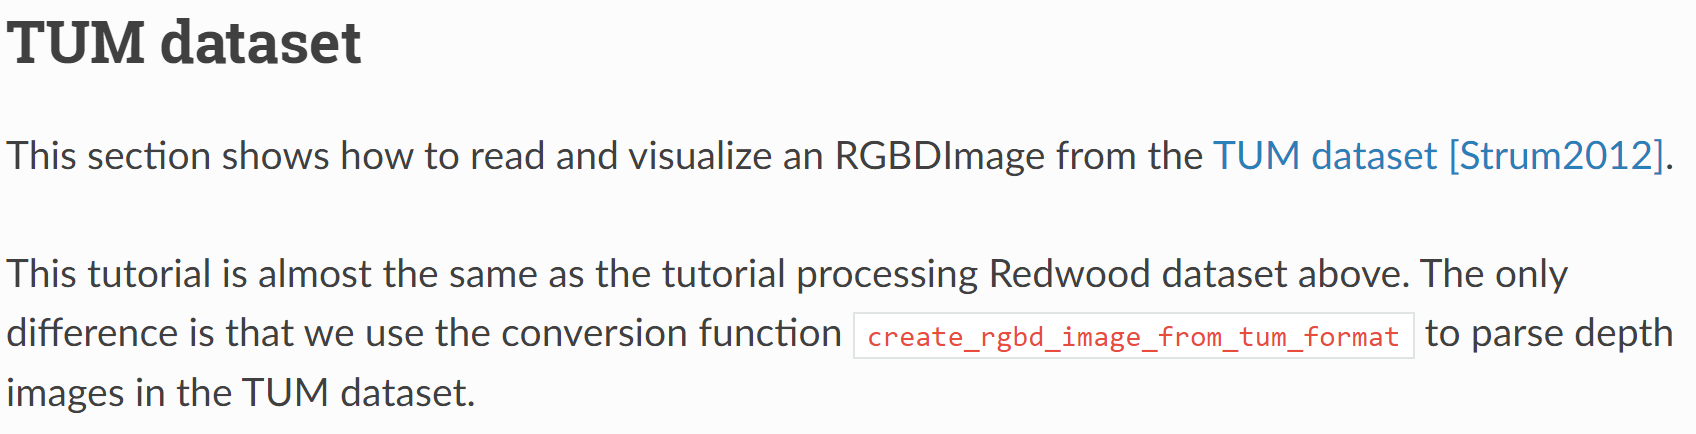

In [ ]:
import open3d as o3d
import matplotlib.pyplot as plt
print("Read TUM dataset")
tum_rgbd = o3d.data.SampleTUMRGBDImage()
color_raw = o3d.io.read_image(tum_rgbd.color_path)
depth_raw = o3d.io.read_image(tum_rgbd.depth_path)
trgbd_image = o3d.geometry.RGBDImage.create_from_tum_format(color_raw, depth_raw)
srgbd_image = o3d.geometry.RGBDImage.create_from_sun_format(color_raw, depth_raw)
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(color_raw, depth_raw)
print(rgbd_image)

In [ ]:
plt.subplot(1, 2, 1)
plt.title('TUM grayscale image')
plt.imshow(trgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('TUM depth image')
plt.imshow(trgbd_image.depth)
plt.show()
plt.subplot(1, 2, 1)
plt.title('TUM grayscale image')
plt.imshow(srgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('TUM depth image')
plt.imshow(srgbd_image.depth)
plt.show()
plt.subplot(1, 2, 1)
plt.title('TUM grayscale image')
plt.imshow(rgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('TUM depth image')
plt.imshow(rgbd_image.depth)
plt.show()

In [ ]:
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    trgbd_image,
    o3d.camera.PinholeCameraIntrinsic(
        o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault))
# Flip it, otherwise the pointcloud will be upside down
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
o3d.visualization.draw_geometries([pcd])

| Dataset | 深度單位 | 深度影像格式 | RGB 與 Depth 對齊 | Open3D 讀取函式 |
|---------|-----------|----------------|----------------------|-------------------------|
| TUM RGB-D | mm | 16-bit PNG | 未對齊，需要手動對齊 | create_from_tum_format |
| NYU Depth v2 | 1/5000 meter | 16-bit PNG | 已對齊 | create_from_nyu_format |
| SUN3D | mm | 16-bit PNG | 已對齊 | create_from_sun_format |
| Redwood | mm | 16-bit PNG | 已對齊 | create_from_redwood_format |

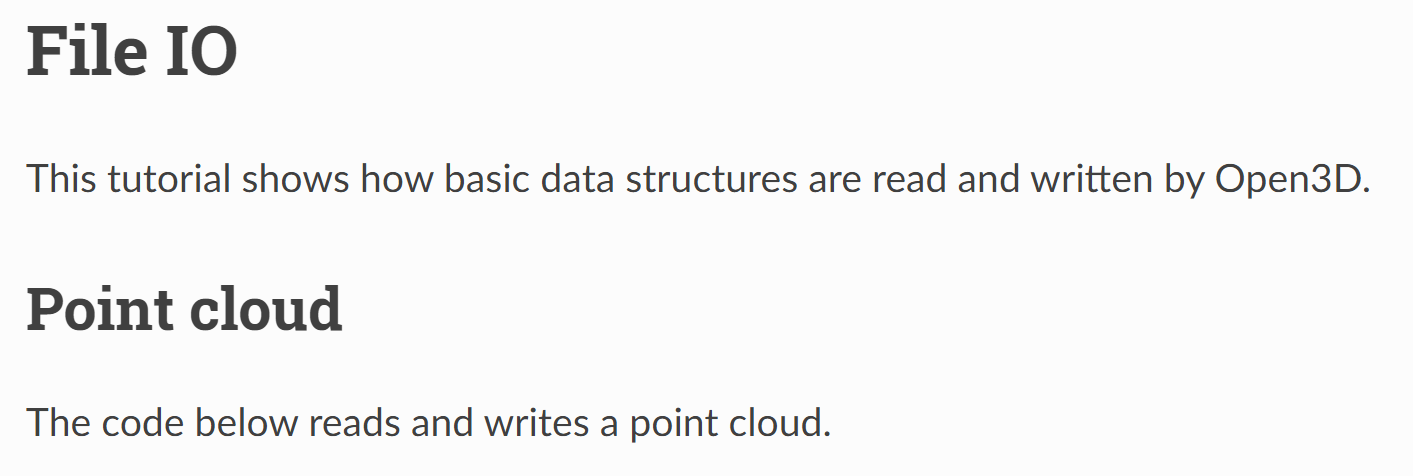
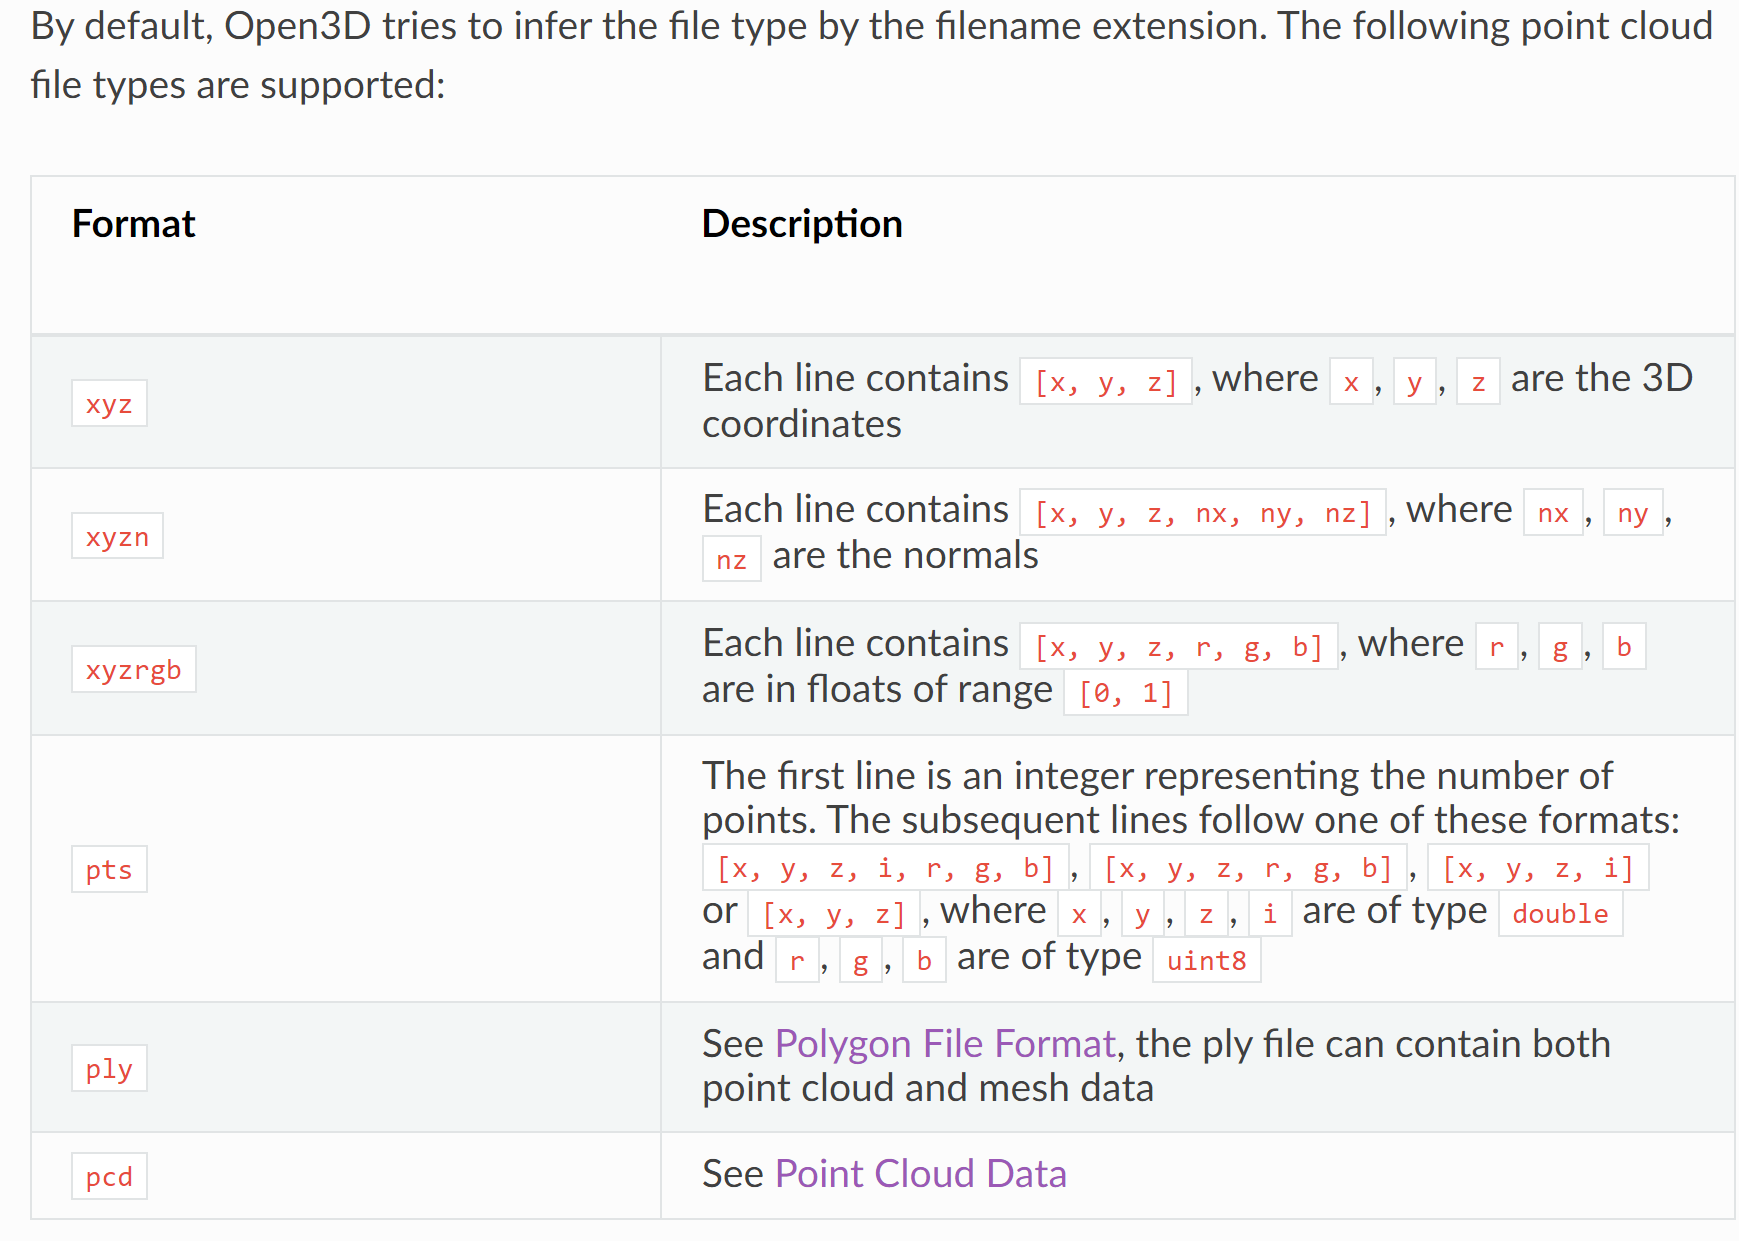

In [ ]:
print("Testing IO for point cloud ...")
sample_pcd_data = o3d.data.PCDPointCloud()
pcd = o3d.io.read_point_cloud(sample_pcd_data.path)
print(pcd)
o3d.io.write_point_cloud("copy_of_fragment.pcd", pcd)

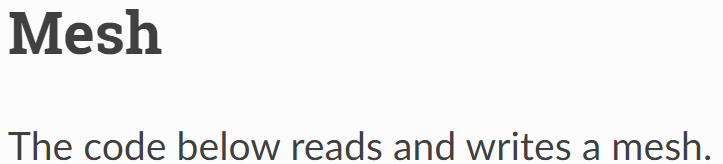
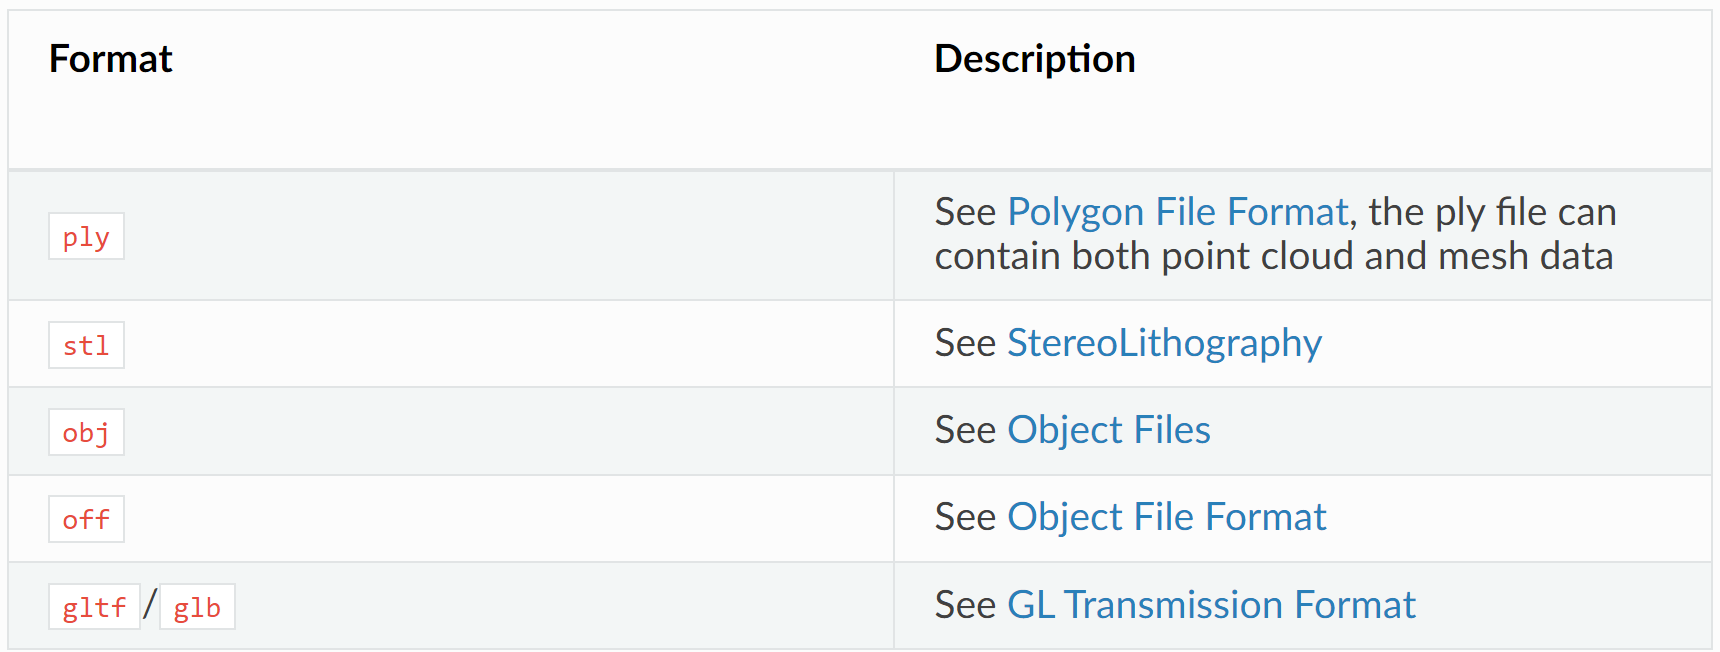

In [ ]:
print("Testing IO for images ...")
image_data = o3d.data.JuneauImage()
img = o3d.io.read_image(image_data.path)
print(img)
o3d.io.write_image("copy_of_Juneau.jpg", img)

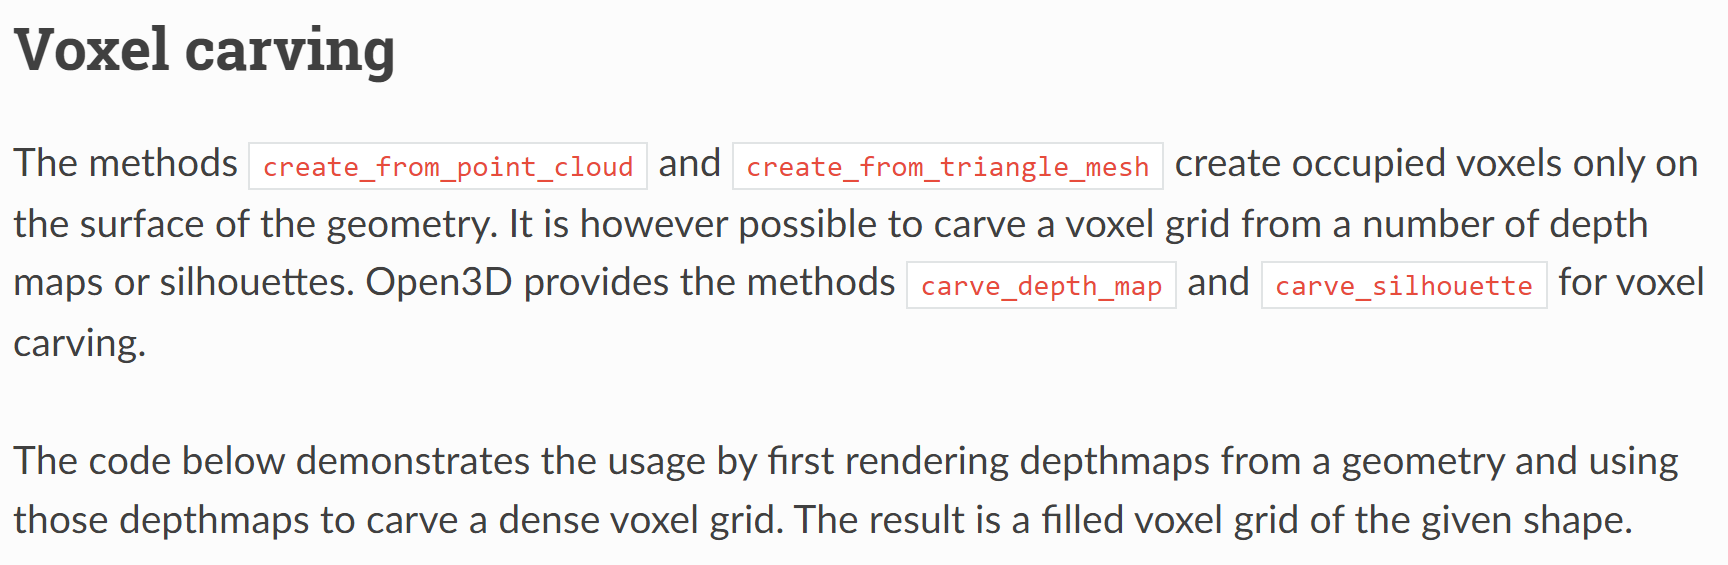

In [1]:
import open3d as o3d
import numpy as np

# 將三維直角座標 xyz 轉換成球座標 (r, r_x, r_y)
# r  ：點到原點的距離
# r_x：與 y 軸的夾角（用 arccos 計算）
# r_y：在 x–z 平面上的方位角（用 arctan2 計算）
def xyz_spherical(xyz):
    x = xyz[0]
    y = xyz[1]
    z = xyz[2]
    r = np.sqrt(x * x + y * y + z * z)
    r_x = np.arccos(y / r)
    r_y = np.arctan2(z, x)
    return [r, r_x, r_y]


# 根據兩個角度 r_x, r_y 建立旋轉矩陣
# r_x：繞 x 軸旋轉的角度
# r_y：繞 y 軸旋轉的角度
# 回傳：先繞 x 再繞 y 的 3x3 旋轉矩陣
def get_rotation_matrix(r_x, r_y):
    # x 軸旋轉矩陣
    rot_x = np.asarray([[1, 0, 0],
                        [0, np.cos(r_x), -np.sin(r_x)],
                        [0, np.sin(r_x), np.cos(r_x)]])
    # y 軸旋轉矩陣
    rot_y = np.asarray([[np.cos(r_y), 0, np.sin(r_y)],
                        [0, 1, 0],
                        [-np.sin(r_y), 0, np.cos(r_y)]])
    # 先 rot_x 再 rot_y
    return rot_y.dot(rot_x)


# 根據一個 3D 位置 xyz 產生相機的 4x4 外部參數矩陣 (extrinsic)
# 這裡的設計是：
#   - 利用 xyz 的方向決定相機的旋轉（由球座標換成旋轉矩陣）
#   - 平移 t 固定放在 [0, 0, 2]
# 回傳：4x4 齊次變換矩陣（旋轉 + 平移）
def get_extrinsic(xyz):
    # 把 xyz 轉成球座標，取出兩個角 r_x, r_y
    rvec = xyz_spherical(xyz)
    r = get_rotation_matrix(rvec[1], rvec[2])
    # 相機的位置（平移向量），這邊固定在 z=2 的位置
    t = np.asarray([0, 0, 2]).transpose()
    # 組 4x4 齊次變換矩陣
    trans = np.eye(4)
    trans[:3, :3] = r
    trans[:3, 3] = t
    return trans


# 對輸入的 mesh 做「中心化 + 正規化」的預處理
# 目的：
#   - 把 mesh 移到原點附近（減去中心）
#   - 再依 bounding box 的大小做縮放，讓模型落在 [-1, 1] 立方體左右的範圍
def preprocess(model):
    # 取得 mesh 的 AABB 最小與最大點
    min_bound = model.get_min_bound()
    max_bound = model.get_max_bound()
    # 計算中心點與尺度
    center = min_bound + (max_bound - min_bound) / 2.0
    scale = np.linalg.norm(max_bound - min_bound) / 2.0
    # 對頂點做平移與縮放
    vertices = np.asarray(model.vertices)
    vertices -= center
    model.vertices = o3d.utility.Vector3dVector(vertices / scale)
    return model


# 主要的 voxel carving 函式
# mesh            ：輸入的三角網格模型
# cubic_size      ：voxel grid 立方體的物理尺寸（邊長）
# voxel_resolution：voxel grid 在一個維度上的解析度（例如 256 -> 256^3）
# w, h            ：用來 render depth map 的視窗寬高
# use_depth       ：True -> 用 depth map carving；False -> 用 silhouette carving
# surface_method  ：'pointcloud' 或 'mesh'，用哪一種幾何來建表面的 voxel grid
# 回傳：
#   voxel_carving_surface：surface voxel + carving 結果疊加
#   voxel_carving        ：carving 後剩下的 voxel grid（體素內部）
#   voxel_surface        ：由 point cloud 或 mesh 建出來的外表面 voxel grid
def voxel_carving(mesh,
                  cubic_size,
                  voxel_resolution,
                  w=300,
                  h=300,
                  use_depth=False,
                  surface_method='pointcloud'):
    # 先計算法向量，讓渲染結果比較正確
    mesh.compute_vertex_normals()
    # 建一個球來當「相機軌道」，球面上的點是相機位置參考
    camera_sphere = o3d.geometry.TriangleMesh.create_sphere()

    # === 建立 dense voxel grid（體素立方體） ===
    voxel_carving = o3d.geometry.VoxelGrid.create_dense(
        width=cubic_size,
        height=cubic_size,
        depth=cubic_size,
        voxel_size=cubic_size / voxel_resolution,
        # 立方體的左下後角在 (-cubic_size/2, -cubic_size/2, -cubic_size/2)
        origin=[-cubic_size / 2.0, -cubic_size / 2.0, -cubic_size / 2.0],
        color=[1.0, 0.7, 0.0])  # 體素顏色（橘色）
    o3d.visualization.draw_geometries([voxel_carving])
    
    # === 將相機球與 mesh 做中心化 + 縮放，放進同一個 [-1,1]^3 空間 ===
    camera_sphere = preprocess(camera_sphere)
    mesh = preprocess(mesh)

    # === 建立一個「看不見視窗的」Visualizer，用來 Render 深度影像 ===
    vis = o3d.visualization.Visualizer()
    vis.create_window(width=w, height=h, visible=False)  # invisible offscreen window
    vis.add_geometry(mesh)
    # 顯示背面，以免某些角度看不到幾何
    vis.get_render_option().mesh_show_back_face = True
    ctr = vis.get_view_control()
    # 取得 pinhole camera 的參數（內部+外部）
    param = ctr.convert_to_pinhole_camera_parameters()

    # === 開始繞著模型做 voxel carving ===
    pcd_agg = o3d.geometry.PointCloud()                 # 累積所有視角的點雲
    centers_pts = np.zeros((len(camera_sphere.vertices), 3))  # 記錄相機中心位置
    for cid, xyz in enumerate(camera_sphere.vertices):
        # 1. 依照球面上的一個點 xyz，計算對應相機的外部矩陣
        trans = get_extrinsic(xyz)
        param.extrinsic = trans
        # 相機中心 c = trans^-1 * [0,0,0,1]^T
        c = np.linalg.inv(trans).dot(np.asarray([0, 0, 0, 1]).transpose())
        centers_pts[cid, :] = c[:3]
        # 更新視角，allow_arbitrary=True 允許非預設姿態
        ctr.convert_from_pinhole_camera_parameters(param, allow_arbitrary=True)

        # 2. 渲染深度圖（depth map），再轉成點雲
        vis.poll_events()
        vis.update_renderer()
        depth = vis.capture_depth_float_buffer(False)  # 取得深度影像（float buffer）
        pcd_agg += o3d.geometry.PointCloud.create_from_depth_image(
            o3d.geometry.Image(depth),
            param.intrinsic,
            param.extrinsic,
            depth_scale=1)   # 這裡深度就是 meter / world unit，所以 scale=1
        
        # 3. 用深度圖對 voxel grid 做 carving（體素刨除）
        #    use_depth=True  -> 使用 carve_depth_map
        #    use_depth=False -> 使用 carve_silhouette
        if use_depth:
            # 利用 depth map 保留靠近表面的體素，刨除其他部分
            voxel_carving.carve_depth_map(o3d.geometry.Image(depth), param)
        else:
            # 只根據前景/背景 silhouette 來刨除 voxels
            voxel_carving.carve_silhouette(o3d.geometry.Image(depth), param)
        print("Carve view %03d/%03d" % (cid + 1, len(camera_sphere.vertices)))
        
    vis.destroy_window()

    # === 從 carved 出來的點雲或 mesh 建立「表面」的 voxel grid ===
    print('Surface voxel grid from %s' % surface_method)
    if surface_method == 'pointcloud':
        # 用累積的點雲 pcd_agg 建 voxel grid（表面）
        voxel_surface = o3d.geometry.VoxelGrid.create_from_point_cloud_within_bounds(
            pcd_agg,
            voxel_size=cubic_size / voxel_resolution,
            min_bound=(-cubic_size / 2, -cubic_size / 2, -cubic_size / 2),
            max_bound=(cubic_size / 2, cubic_size / 2, cubic_size / 2))
    elif surface_method == 'mesh':
        # 直接用 mesh 幾何來建 voxel grid（表面）
        voxel_surface = o3d.geometry.VoxelGrid.create_from_triangle_mesh_within_bounds(
            mesh,
            voxel_size=cubic_size / voxel_resolution,
            min_bound=(-cubic_size / 2, -cubic_size / 2, -cubic_size / 2),
            max_bound=(cubic_size / 2, cubic_size / 2, cubic_size / 2))
    else:
        raise Exception('invalid surface method')

    # voxel_carving_surface = 表面 voxel + 體積 carving 結果疊加
    voxel_carving_surface = voxel_surface + voxel_carving

    return voxel_carving_surface, voxel_carving, voxel_surface
    

# === 測試：讀取範例 Armadillo mesh，並做 voxel carving ===
armadillo = o3d.data.ArmadilloMesh()
mesh = o3d.io.read_triangle_mesh(armadillo.path)
o3d.visualization.draw_geometries([mesh])

visualization = True
cubic_size = 2.0         # voxel 空間的立方體邊長
voxel_resolution = 256.0 # 每一維的 voxel 數量

# 執行 voxel carving，得到：
#   voxel_grid        ：表面 + 體積的綜合結果
#   voxel_carving     ：純 carving 過後的體素（內部／實心）
#   voxel_surface     ：由點雲或 mesh 建出來的表面體素
voxel_grid, voxel_carving, voxel_surface = voxel_carving(
    mesh, cubic_size, voxel_resolution
)

2025-11-20 23:21:03.935 python[2835:41189] TSM AdjustCapsLockLEDForKeyTransitionHandling - _ISSetPhysicalKeyboardCapsLockLED Inhibit
2025-11-20 23:21:03.941 python[2835:41189] error messaging the mach port for IMKCFRunLoopWakeUpReliable
2025-11-20 23:23:41.496 python[2835:41389] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0x33acfffc0 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-11-20 23:24:43.408 python[2835:41360] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=

Carve view 001/762
Carve view 002/762
Carve view 003/762
Carve view 004/762
Carve view 005/762
Carve view 006/762
Carve view 007/762
Carve view 008/762
Carve view 009/762
Carve view 010/762
Carve view 011/762
Carve view 012/762
Carve view 013/762
Carve view 014/762
Carve view 015/762
Carve view 016/762
Carve view 017/762
Carve view 018/762
Carve view 019/762
Carve view 020/762
Carve view 021/762
Carve view 022/762
Carve view 023/762
Carve view 024/762
Carve view 025/762
Carve view 026/762
Carve view 027/762
Carve view 028/762
Carve view 029/762
Carve view 030/762
Carve view 031/762
Carve view 032/762
Carve view 033/762
Carve view 034/762
Carve view 035/762
Carve view 036/762
Carve view 037/762
Carve view 038/762
Carve view 039/762
Carve view 040/762
Carve view 041/762
Carve view 042/762
Carve view 043/762
Carve view 044/762
Carve view 045/762
Carve view 046/762
Carve view 047/762
Carve view 048/762
Carve view 049/762
Carve view 050/762
Carve view 051/762
Carve view 052/762
Carve view 0

In [2]:
print("surface voxels")
print(voxel_surface)
o3d.visualization.draw_geometries([voxel_surface])

print("carved voxels")
print(voxel_carving)
o3d.visualization.draw_geometries([voxel_carving])

print("combined voxels (carved + surface)")
print(voxel_grid)
o3d.visualization.draw_geometries([voxel_grid])

surface voxels
VoxelGrid with 82408 voxels.
carved voxels
VoxelGrid with 387212 voxels.
combined voxels (carved + surface)
VoxelGrid with 389902 voxels.


### 自訂 voxel carving 任務
我選擇使用 Open3D 的 Knot mesh，調整 cubic_size 與 voxel 解析度後執行 voxel carving，並將結果存成檔案與截圖。


Carved 20/182 views
Carved 40/182 views
Carved 60/182 views
Carved 80/182 views
Carved 100/182 views
Carved 120/182 views
Carved 140/182 views
Carved 160/182 views
Carved 180/182 views
Carved 182/182 views


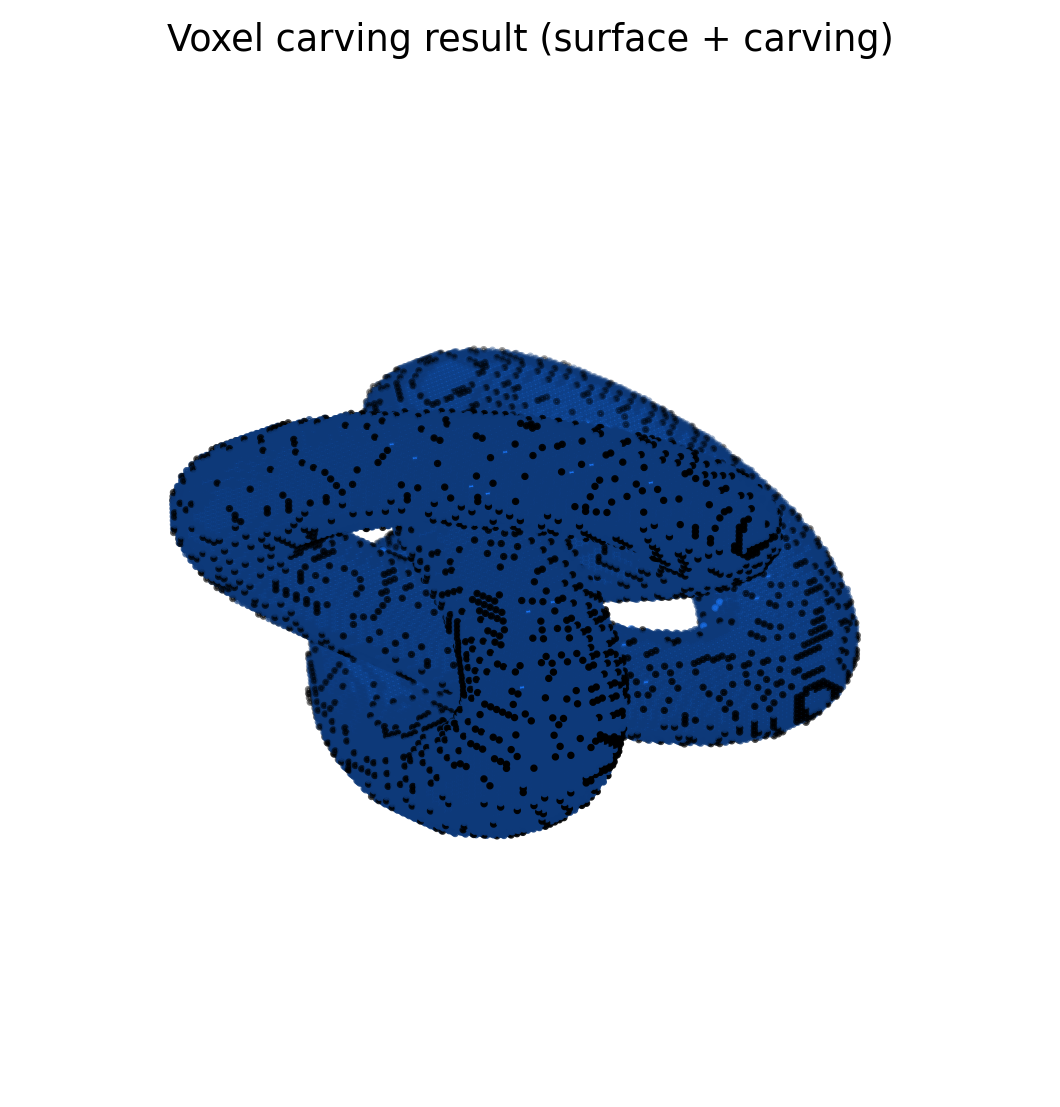

Saved combined voxel grid to knot_voxel_grid.ply
Visualizing 182559 voxels
Screenshot saved to knot_voxel_grid.png


In [1]:
import copy
import numpy as np
import open3d as o3d
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from IPython.display import Image as IPyImage, display


def _normalize_mesh_for_voxel(model):
    min_bound = model.get_min_bound()
    max_bound = model.get_max_bound()
    center = min_bound + (max_bound - min_bound) / 2.0
    scale = np.linalg.norm(max_bound - min_bound) / 2.0
    vertices = np.asarray(model.vertices)
    vertices = (vertices - center) / scale
    model.vertices = o3d.utility.Vector3dVector(vertices)
    return model


def _camera_extrinsic_from_xyz(xyz):
    x, y, z = xyz
    r = np.sqrt(x * x + y * y + z * z)
    r_x = np.arccos(y / r)
    r_y = np.arctan2(z, x)
    rot_x = np.asarray([[1, 0, 0],
                        [0, np.cos(r_x), -np.sin(r_x)],
                        [0, np.sin(r_x), np.cos(r_x)]])
    rot_y = np.asarray([[np.cos(r_y), 0, np.sin(r_y)],
                        [0, 1, 0],
                        [-np.sin(r_y), 0, np.cos(r_y)]])
    rot = rot_y.dot(rot_x)
    trans = np.eye(4)
    trans[:3, :3] = rot
    trans[:3, 3] = np.asarray([0, 0, 2])
    return trans


def voxel_carving_batch(mesh,
                        cubic_size,
                        voxel_resolution,
                        w=512,
                        h=512,
                        use_depth=True,
                        surface_method='pointcloud',
                        camera_resolution=10):
    mesh = _normalize_mesh_for_voxel(copy.deepcopy(mesh))
    mesh.compute_vertex_normals()
    camera_sphere = _normalize_mesh_for_voxel(
        o3d.geometry.TriangleMesh.create_sphere(radius=1.0, resolution=camera_resolution))

    voxel_carving = o3d.geometry.VoxelGrid.create_dense(
        width=cubic_size,
        height=cubic_size,
        depth=cubic_size,
        voxel_size=cubic_size / voxel_resolution,
        origin=[-cubic_size / 2.0, -cubic_size / 2.0, -cubic_size / 2.0],
        color=[0.1, 0.45, 0.95])

    vis = o3d.visualization.Visualizer()
    vis.create_window(width=w, height=h, visible=False)
    vis.add_geometry(mesh)
    vis.get_render_option().mesh_show_back_face = True
    ctr = vis.get_view_control()
    param = ctr.convert_to_pinhole_camera_parameters()

    pcd_agg = o3d.geometry.PointCloud()
    vertices = np.asarray(camera_sphere.vertices)
    total_views = len(vertices)
    for cid, xyz in enumerate(vertices):
        trans = _camera_extrinsic_from_xyz(xyz)
        param.extrinsic = trans
        ctr.convert_from_pinhole_camera_parameters(param, allow_arbitrary=True)
        vis.poll_events()
        vis.update_renderer()
        depth = vis.capture_depth_float_buffer(False)
        depth_image = o3d.geometry.Image(depth)
        pcd_agg += o3d.geometry.PointCloud.create_from_depth_image(
            depth_image,
            param.intrinsic,
            param.extrinsic,
            depth_scale=1.0)
        if use_depth:
            voxel_carving.carve_depth_map(depth_image, param)
        else:
            voxel_carving.carve_silhouette(depth_image, param)
        if (cid + 1) % 20 == 0 or cid + 1 == total_views:
            print(f"Carved {cid + 1}/{total_views} views")

    vis.destroy_window()

    min_bound = (-cubic_size / 2, -cubic_size / 2, -cubic_size / 2)
    max_bound = (cubic_size / 2, cubic_size / 2, cubic_size / 2)
    if surface_method == 'pointcloud':
        voxel_surface = o3d.geometry.VoxelGrid.create_from_point_cloud_within_bounds(
            pcd_agg,
            voxel_size=cubic_size / voxel_resolution,
            min_bound=min_bound,
            max_bound=max_bound)
    else:
        voxel_surface = o3d.geometry.VoxelGrid.create_from_triangle_mesh_within_bounds(
            mesh,
            voxel_size=cubic_size / voxel_resolution,
            min_bound=min_bound,
            max_bound=max_bound)

    voxel_carving_surface = voxel_surface + voxel_carving
    return voxel_carving_surface, voxel_carving, voxel_surface


def voxel_grid_to_arrays(voxel_grid):
    voxels = voxel_grid.get_voxels()
    centers = np.asarray([
        voxel_grid.origin +
        (np.asarray(voxel.grid_index, dtype=float) + 0.5) * voxel_grid.voxel_size
        for voxel in voxels
    ])
    colors = np.asarray([voxel.color for voxel in voxels])
    return centers, colors


knot_mesh = o3d.data.KnotMesh()
knot_model = o3d.io.read_triangle_mesh(knot_mesh.path)
knot_model.compute_vertex_normals()

cubic_size = 2.4
voxel_resolution = 180.0
voxel_grid_knot, voxel_carving_knot, voxel_surface_knot = voxel_carving_batch(
    knot_model,
    cubic_size=cubic_size,
    voxel_resolution=voxel_resolution,
    w=512,
    h=512,
    use_depth=True,
    surface_method='pointcloud',
    camera_resolution=10)

voxel_path = Path('knot_voxel_grid.ply')
o3d.io.write_voxel_grid(str(voxel_path), voxel_grid_knot)

centers, colors = voxel_grid_to_arrays(voxel_grid_knot)
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=25.0, azim=45.0)
ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], c=colors, s=2)
ax.set_title('Voxel carving result (surface + carving)')
ax.set_axis_off()
screenshot_path = Path('knot_voxel_grid.png')
fig.savefig(screenshot_path, dpi=220, bbox_inches='tight')
plt.close(fig)

display(IPyImage(filename=str(screenshot_path)))
print(f"Saved combined voxel grid to {voxel_path}")
print(f"Visualizing {centers.shape[0]} voxels")
print(f"Screenshot saved to {screenshot_path}")


輸出檔案：`knot_voxel_grid.ply` 與 `knot_voxel_grid.png`，已儲存在當前目錄，方便後續檢查。
